<a href="https://colab.research.google.com/github/nichmars/Johnson-Center-GVSU-Final-Project/blob/main/k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import sklearn.model_selection
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler

from google.colab import drive
drive.mount('/content/drive')
file_name = '/content/drive/MyDrive/MTH498 Project/Filtered Data with Subtypes Again.xlsx'

df = pd.read_excel(file_name)

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

Mounted at /content/drive


In [2]:
from sklearn.model_selection import train_test_split

metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Code to limit the data to just 2022 and 2023
# df = df.loc[(df['Year'] == 2022) | (df['Year'] == 2023)]


# Split EINs into train/test
# Get a list of unique EINs to split up our data based on EIN
unique_eins = df["ein"].unique()

# Split up the unique eins, putting 25% of the data in the test set. Uses seed 42 to ensure consistency.
train_eins, test_eins = train_test_split(
    unique_eins,
    test_size=0.25,
    random_state=42
)

train_df = df[df["ein"].isin(train_eins)].copy()
test_df = df[df["ein"].isin(test_eins)].copy()

In [3]:
# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()


# Assign each org to a growth bracket by metric
# Optional code in here for scaling the data, it's not necessary in this case
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    # Prepping data for KMeans clustering
    temp_df = train_df[[m]].copy()
    #scaler = StandardScaler()
    #temp_df = scaler.fit_transform(temp_df)

    # Creating clusters for the training data
    kmeans = KMeans(n_clusters=4, random_state=42)
    train_df[f'{m.lower()}_group'] = kmeans.fit_predict(X = temp_df)

    # Applying those clusters to the test data
    temp_test_df = test_df[[m]].copy()
    #temp_test_df = scaler.fit_transform(temp_test_df)
    test_df[f'{m.lower()}_group'] = kmeans.predict(temp_test_df)


    # # Splitting data into groups by numerical value:
    # df[f'{m.lower()}_group'] = pd.qcut(df[m], q=50, labels=False, duplicates='drop')


# Combining train and test group assignments
groups_df = pd.concat([
    train_df.filter(regex='_group$'),
    test_df.filter(regex='_group$')
]).sort_index()

# Merge back to original df
df = df.join(groups_df)

# Loop through each metric to calculate percent change
# Use .replace(np.nan, 0) to catch 0/0 errors and manually adjust the percent change to 0
# Still has an error where if a value goes from 0 to a non-zero number, the percent change is inf
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    # temp_train_df_1 = train_df
    # temp_train_df_1[m] = train_df[m].replace(0, 0.0001)
    df[pct_col] = train_df.groupby("ein")[m].pct_change().replace(np.nan, 0)
    df.loc[df["year_diff"] != 1, pct_col] = None

#print(df[f'{m.lower()}_group'].value_counts())

In [4]:
# Compute median growth per bracket, Year, Type, subtype for each metric
group_col = [f'{m.lower()}_group' for m in metrics]
pct_col = [f"{m.lower()}_pct_change" for m in metrics]

# Use previously determined groupings, find the median of these groupings, and assign percent change values
# then merge to original dataframe
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    group_col = f'{m.lower()}_group'
    median_col = f"median_{m.lower()}_growth"

    group_medians = (
        df.groupby(group_col)[pct_col]
        .median()
        .reset_index()
        .rename(columns={pct_col: median_col})
    )

    df = df.merge(group_medians, on=[group_col], how="left")


# Predict next year's value using each org's bracket-specific median growth
for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)
    df[f"predicted_{m.lower()}"] = prev_actual * (1 + df[f"median_{m.lower()}_growth"])

# Combining predicted columns to the test dataframe
predicted_df = df.filter(regex='predicted_')
test_df = test_df.join(predicted_df)

In [5]:
# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions", "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(test_df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate Median Relative Deviation
def MRD(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() &
                    df[actual_col].notna() &
                    (df[actual_col] != 0) &
                    (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted)) / total_actual).median()
    return RE

def mean_relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).mean()
    return RE

def smape(actual_col, predicted_col):
    valid_rows = df[
        df[predicted_col].notna() &
        df[actual_col].notna() &
        (df["year_diff"] == 1)
    ]

    A = valid_rows[actual_col]
    P = valid_rows[predicted_col]

    return np.mean(np.abs(A - P) / ((np.abs(A) + np.abs(P)) / 2))

# Compute relative errors
RE_account = MRD("Accounts", "predicted_accounts")
RE_contributions = MRD("Contributions", "predicted_contributions")
RE_grants = MRD("Grants", "predicted_grants")
RE_assets = MRD("Assets", "predicted_assets")

Mean_account = mean_relative_error("Accounts", "predicted_accounts")
Mean_contributions = mean_relative_error("Contributions", "predicted_contributions")
Mean_grants = mean_relative_error("Grants", "predicted_grants")
Mean_assets = mean_relative_error("Assets", "predicted_assets")

smape_account = smape("Accounts", "predicted_accounts")
smape_contributions = smape("Contributions", "predicted_contributions")
smape_grants = smape("Grants", "predicted_grants")
smape_assets = smape("Assets", "predicted_assets")

print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

print("")
print("Mean Relative Deviation - Account:", abs(Mean_account))
print("Mean Relative Deviation - Contributions:", abs(Mean_contributions))
print("Mean Relative Deviation - Grants:", abs(Mean_grants))
print("Mean Relative Deviation - Assets:", abs(Mean_assets))

print("")
print("SMAPE - Account:", abs(smape_account))
print("SMAPE - Contributions:", abs(smape_contributions))
print("SMAPE - Grants:", abs(smape_grants))
print("SMAPE - Assets:", abs(smape_assets))

Median Relative Deviation - Account: 0.04716024340770777
Median Relative Deviation - Contributions: 0.5027269009536557
Median Relative Deviation - Grants: 0.3039140600864612
Median Relative Deviation - Assets: 0.11659530358751827

Mean Relative Deviation - Account: 0.1589716083047901
Mean Relative Deviation - Contributions: 2.7748661986655145
Mean Relative Deviation - Grants: 1.5937436457554188
Mean Relative Deviation - Assets: 0.9163219978227104

SMAPE - Account: 0.12782564898525542
SMAPE - Contributions: 0.7000030442558137
SMAPE - Grants: 0.5017991440891422
SMAPE - Assets: 0.22862071593999153


In [6]:
#df.to_excel("output.xlsx", index=False)

In [7]:
df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]

accounts_group
0    8835
3     120
1      46
2      22
Name: count, dtype: int64


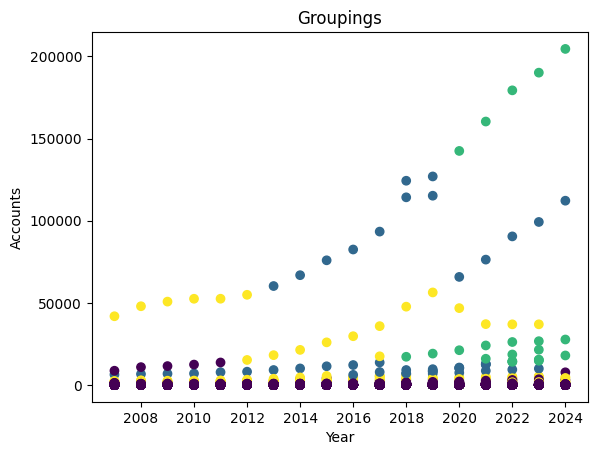

contributions_group
0    8941
2      72
1       8
3       2
Name: count, dtype: int64


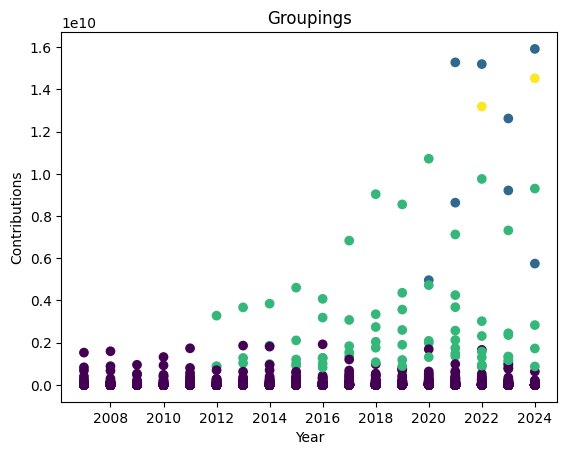

grants_group
0    8954
2      50
3      14
1       5
Name: count, dtype: int64


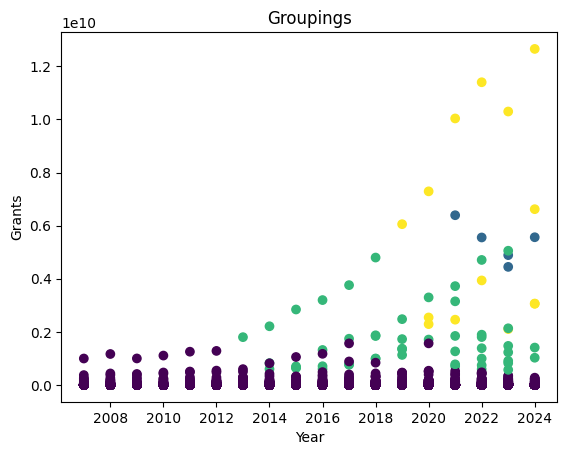

assets_group
0    8968
2      43
1      11
3       1
Name: count, dtype: int64


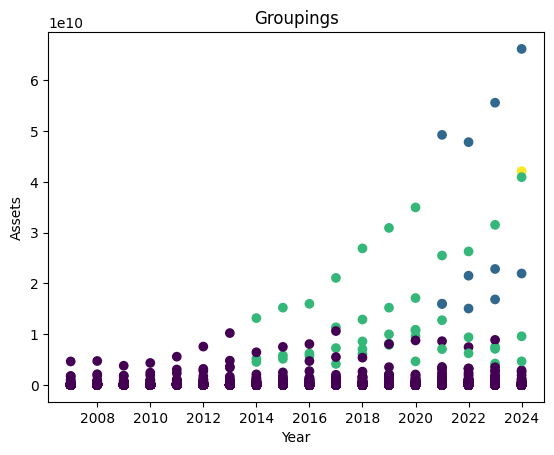

In [8]:
for m in metrics:
  print(df[f'{m.lower()}_group'].value_counts())
  fig, ax = plt.subplots()
  ax.scatter(x = df["Year"], y = df[m], c = df[f'{m.lower()}_group'])
  ax.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax.set_xlabel("Year")
  ax.set_ylabel(f'{m.title()}')
  ax.set_title("Groupings")
  plt.show()

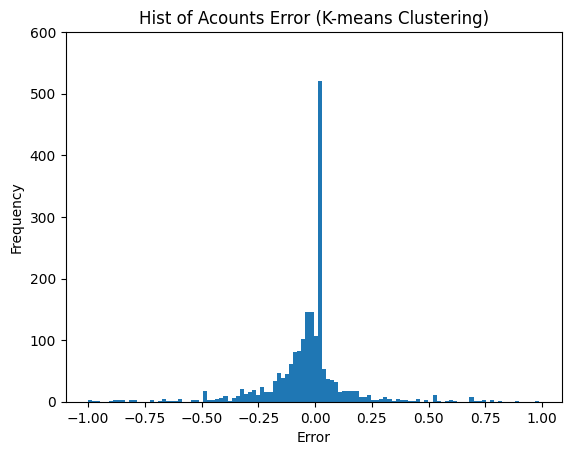

In [9]:
df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error (K-means Clustering)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0,600) #
plt.show()

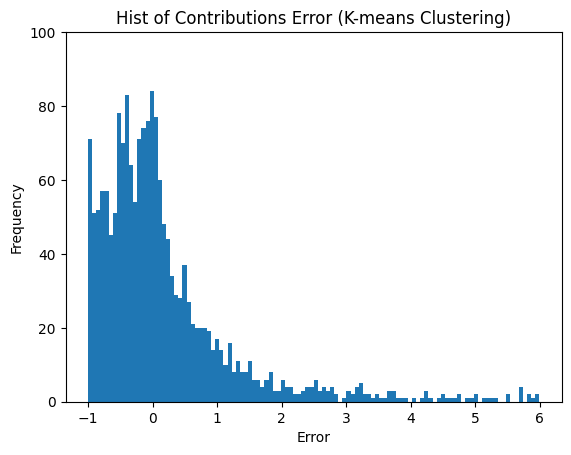

In [10]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error (K-means Clustering)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 100) #
plt.show()

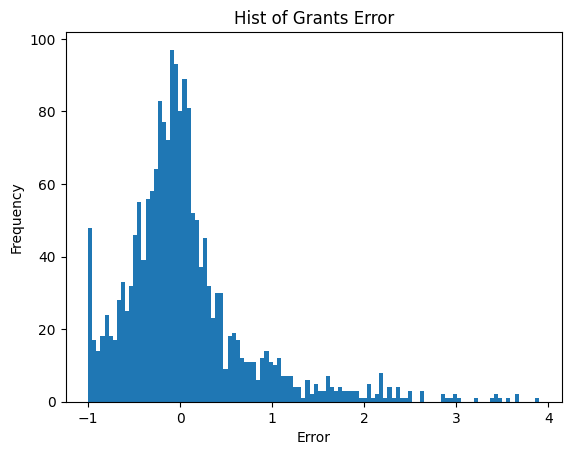

In [11]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

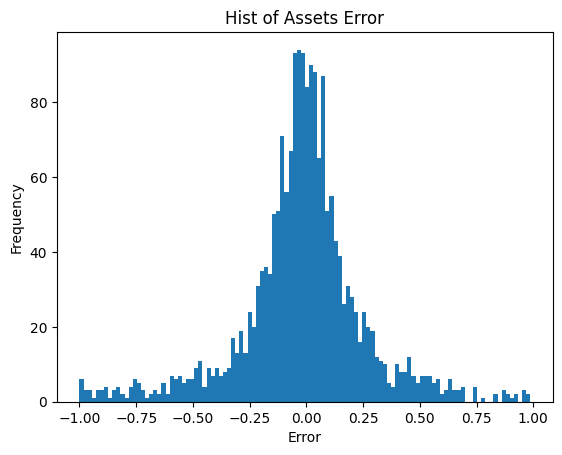

In [12]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

/tmp/ipykernel_523/4203719913.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_523/4203719913.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_523/4203719913.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_523/4203719913.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


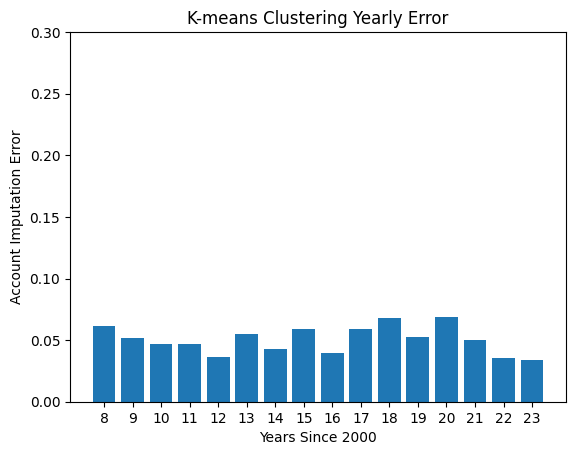

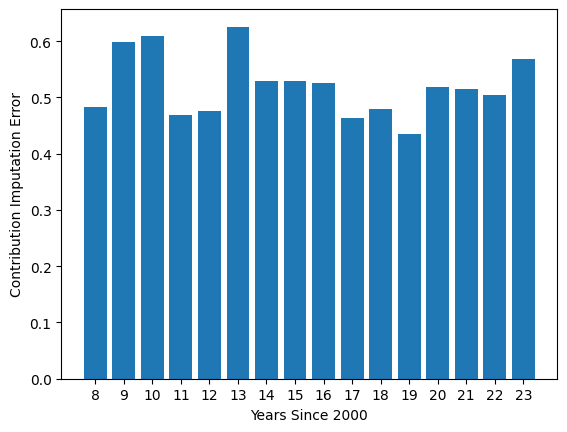

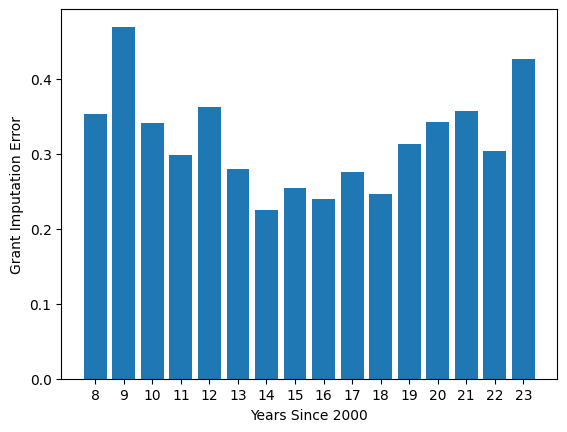

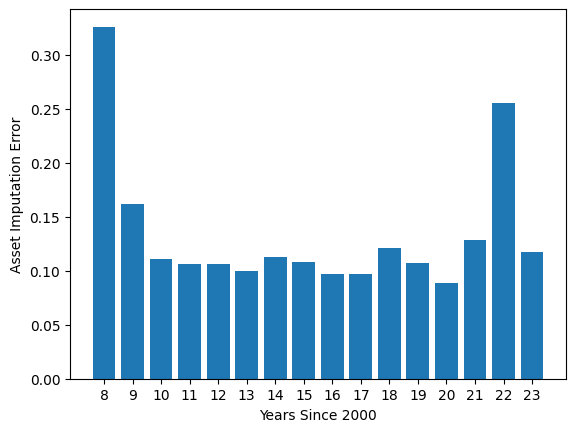

In [13]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

# def relative_grouped_error(actual_col, predicted_col):
#     valid_rows = group[group[predicted_col].notna()]
#     total_actual = valid_rows[actual_col].sum()
#     total_predicted = valid_rows[predicted_col].sum()
#     RE = abs((total_actual - total_predicted) / total_actual)
#     return RE

community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))
#2024 is discounted from these graphs because the error is exponentially greater than the rest
#2020/2021 was Covid, 2014 was when the stock market rebounded, and 2008/2009 was an economic recession
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.title("K-means Clustering Yearly Error")
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.ylim(0,0.3)
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()